### Import

In [1]:
import os
import sys
import re
import random
import numpy as np
import pandas as pd
import datetime as dt
from tqdm import tqdm
from matplotlib import pyplot as plt

from multiprocessing import Pool
from multiprocessing import cpu_count

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
path_timeseries = '../Data/Output/'

### Read csv files

In [3]:
def dataframe_from_csv(path, header=0, index_col=False):
    return pd.read_csv(path, header=header, index_col=index_col)

### Select Variables

In [1]:
columns = ['patientid', 'datetime', 'Heart Rate', 'Temperature Central', 'Invasive systolic arterial pressure',
           'Invasive diastolic arterial pressure', 'Invasive mean arterial pressure',
           'Non-invasive systolic arterial pressure', 'Non-invasive diastolic arterial pressure',
           'Non-invasive mean arterial pressure', 'Pulmonary artery mean pressure',
           'Pulmonary artery systolic pressure', 'Pulmonary artery diastolic pressure',
           'Pulmonary artery wedge pressure', 'Cardiac Output', 'SvO2(m)', 'Central venous pressure', 
           'ST1 (ECG ST elevation)', 'ST2 (ECG ST elevation)', 'ST3 (ECG ST elevation)', 
           'SpO2', 'ETCO2', 'Respiratory Rate', 'ICP', 'TOF', 'FIO2', 'Peep', 'Ventilator mode', 'TV', 
           'Peak Inspiratory Pressure', 'Plateau Pressure', 'Mean Inspiratory Airway Pressure',
           'Respiratory Rate (Set)', 
           'Central venous pressure', 'Heart Rhythm', 'supplemental oxygen', 'GCS Verbal', 'GCS Motor', 
           'GCS Eye', 'RASS', 'ICP', 'Ventilator Airway Code', 'Haemofiltration',
           'Liquor/h (output from drain)', 
           'Base Excess', 'Carboxy Hemoglobin', 'Hemoglobin', 'Bicarbonate',
           'Lactate', 'Methemoglobin', 'pH', 'pCO2', 'PO2', 'Oxygen Saturation_SO2', 'CV Oxygenation Saturation', 
           'Troponin-T', 'Creatine kinase', 'Creatine kinase-MB', 'BNP', 'Potassium', 'Sodium', 'Chloride', 
           'Calcium Ionized', 'Calcium', 'Phosphate', 'Magnesium', 'Urea', 'Creatinine', 'urinary creatinin',
           'urinary sodium', 'urinary urea', 'AST', 'ALT', 'Bilirubine, Total', 'Bilirubin, Direct', 
           'Alkaline Phosphatase', 'gamma-GT', 'PTT', 'Fibrinogen', 'FII', 'Factor V (Coagulation)',
           'Factor VII (Coagulation)', 'Factor X (Coagulation)', 'INR', 'Albumin', 'Glucose', 'Ammonia', 
           'C-reactive protein', 'Procalcitonin', 'Lymphocytes', 'Neutrophils', 'Segmented Neutrophils', 
           'Band Neutrophils', 'BSR', 'White Blood Cell count', 'Platelet Count', 'MCH', 'MCHC', 'MCV',
           'Ferritin', 'TSH', 'Amylase', 'Lipase', 'Cortisol', 'pH Liquor', 'Lactate Liquor', 'Glucose Liquor', 
           'pH Drain', 'Amylase Drain', 
           'Out Urine/h', 'Fluid Balance IN', 'Fluid Balance OUT','Incrys (saline solution)', 'Incolloid', 
           'packed red blood cells', 'FFP', 'platelets',
           'coagulation factors', 'norepinephrine', 'epinephrine', 'dobutamine', 'milrinone', 'levosimendan', 
           'theophyllin', 'vasopressin', 'desmopressin', 'vasodilatators', 'ACE Inhibitors',
           'Sartane', 'Ca Antagonists', 'B-Blocker', 'Andere', 'Adenosin', 'Digoxin', 'Amiodaron', 'Atropin', 
           'K-sparend', 'Aldosteron Antagonist', 'Loop diuretics', 'Thiazide', 'Acetazolamide', 
           'Administriation of antibiotics', 'Administation of antimycotic', 'administration of antiviral',
           'Antihelmenticum', 'Benzodiacepine', 'Alpha 2 Agonisten', 'Barbiturate', 'Propofol', 
           'Glucose Administration', 'Insulin Lantus', 'Insulin Rapid',  'Nimodipin', 'Opiate',
           'Non-opioide', 'NSAR', 'Ketalar', 'Peripherial Anesthesia', 'Steroids', 'Thrombozytenhemmer', 
           'Enteral Feeding', 'Parenteral Feeding', 'Heparin', 'NMH', 'Others in Case of HIT', 'Marcoumar', 
           'Protamin', 'Anti Fibrinolyticum', 'Kalium', 'Phosphat', 'Na', 'Mg', 'Ca', 'Trace elements', 
           'Na-Bicarbonate', 'Antiepileptica', 'Anti delirant medi', 'Psychopharma', 'steroids', 'non-steroids', 
           'Thyrotardin', 'Thyroxin', 'Thyreostatikum', 'Mineralokortikoid', 'Antihistaminka', 'Chemotherapie',
           'Lysetherapie', 'Muskelrelaxans', 'Anexate', 'Naloxon', 'Beh. Pulm. Hypertonie', 'Pankreas Enzyme', 
           'Terlipressin', 'Immunoglobulin', 'Immunsuppression', 'VitB Substitution', 'Parkinson Medikaiton', 
           'GCSF']

In [4]:
vital_columns = [
       'Heart Rate', 'Temperature Central', 'SpO2', 'Invasive systolic arterial pressure',
       'Invasive diastolic arterial pressure', 'Invasive mean arterial pressure',
       'Non-invasive systolic arterial pressure', 'Non-invasive diastolic arterial pressure',
       'Non-invasive mean arterial pressure', 'ST1 (ECG ST elevation)', 'ST2 (ECG ST elevation)', 
       'ST3 (ECG ST elevation)',  'Respiratory Rate']

monitored_columns = [
       'Pulmonary artery mean pressure', 'Pulmonary artery wedge pressure',  
       'Pulmonary artery systolic pressure', 'Pulmonary artery diastolic pressure', 
       'Cardiac Output', 'SvO2(m)','Central venous pressure', 
       'ETCO2',  'ICP', 'TOF', 'FIO2', 'Peep', 'Ventilator mode', 'TV', 'Peak Inspiratory Pressure',
       'Plateau Pressure', 'Mean Inspiratory Airway Pressure', 'Respiratory Rate (Set)']

observed_columns = [
       'Central venous pressure', 'Heart Rhythm', 'supplemental oxygen', 'GCS Verbal', 'GCS Motor', 'GCS Eye', 
       'RASS', 'ICP', 'Ventilator Airway Code', 'Haemofiltration', 'Liquor/h (output from drain)', 'Total GCS']

lab_columns = [
       'Base Excess', 'Carboxy Hemoglobin', 'Hemoglobin', 'Bicarbonate', 'Lactate', 'Methemoglobin', 'pH', 'pCO2', 
       'PO2', 'Oxygen Saturation_SO2', 'CV Oxygenation Saturation', 'Troponin-T', 'Creatine kinase', 
       'Creatine kinase-MB', 'BNP', 'Potassium', 'Sodium', 'Chloride', 'Calcium Ionized', 'Calcium', 'Phosphate',
       'Magnesium', 'Urea', 'Creatinine', 'urinary creatinin', 'urinary sodium', 'urinary urea', 'AST', 'ALT',
       'Bilirubine, Total', 'Bilirubin, Direct', 'Alkaline Phosphatase', 'gamma-GT', 'PTT', 'Fibrinogen', 'FII', 
       'Factor V (Coagulation)', 'Factor VII (Coagulation)', 'Factor X (Coagulation)', 'INR', 'Albumin', 'Glucose',
       'Ammonia', 'C-reactive protein', 'Procalcitonin', 'Lymphocytes', 'Neutrophils', 'Segmented Neutrophils', 
       'Band Neutrophils', 'BSR', 'White Blood Cell count', 'Platelet Count', 'MCH', 'MCHC', 'MCV', 'Ferritin', 
       'TSH', 'Amylase', 'Lipase', 'Cortisol', 'pH Liquor', 'Lactate Liquor', 'Glucose Liquor', 'pH Drain', 
       'Amylase Drain', 'BUN']

derived_columns = ['Out Urine/h', 'Fluid Balance IN', 'Fluid Balance OUT', 'Incrys (saline solution)','Incolloid']

pharma_columns = [
       'packed red blood cells', 'FFP', 'platelets', 'coagulation factors', 'norepinephrine', 'epinephrine',
       'dobutamine', 'milrinone', 'levosimendan', 'theophyllin', 'vasopressin', 'desmopressin', 'vasodilatators', 
       'ACE Inhibitors', 'Sartane', 'Ca Antagonists', 'B-Blocker', 'Andere', 'Adenosin', 'Digoxin', 'Amiodaron', 
       'Atropin', 'K-sparend', 'Aldosteron Antagonist', 'Loop diuretics', 'Thiazide', 'Acetazolamide', 
       'Administriation of antibiotics', 'Administation of antimycotic', 'administration of antiviral', 
       'Antihelmenticum', 'Benzodiacepine', 'Alpha 2 Agonisten', 'Barbiturate', 'Propofol', 
       'Glucose Administration', 'Insulin Lantus', 'Insulin Rapid',  'Nimodipin', 'Opiate', 'Non-opioide', 'NSAR', 
       'Ketalar', 'Peripherial Anesthesia', 'Steroids', 'Thrombozytenhemmer', 'Enteral Feeding', 
       'Parenteral Feeding', 'Heparin', 'NMH', 'Others in Case of HIT', 'Marcoumar', 'Protamin', 
       'Anti Fibrinolyticum', 'Kalium', 'Phosphat', 'Na', 'Mg', 'Ca', 'Trace elements', 'Na-Bicarbonate',
       'Antiepileptica', 'Anti delirant medi', 'Psychopharma', 'steroids', 'non-steroids', 'Thyrotardin', 
       'Thyroxin', 'Thyreostatikum', 'Mineralokortikoid', 'Antihistaminka', 'Chemotherapie', 'Lysetherapie', 
       'Muskelrelaxans', 'Anexate', 'Naloxon', 'Beh. Pulm. Hypertonie', 'Pankreas Enzyme', 'Terlipressin',
       'Immunoglobulin', 'Immunsuppression', 'VitB Substitution', 'Parkinson Medikaiton', 'GCSF', 'vasopressors']

high_freq_cols = vital_columns + monitored_columns + observed_columns + lab_columns + derived_columns

### Variable Estimation

In [6]:
def estimate_gcs(rass):
    
    if   rass >=  0: return 15
    elif rass == -1: return 14
    elif rass == -2: return 12
    elif rass == -3: return 11
    elif rass == -4: return 6
    elif rass == -5: return 3
    
    return pd.NA

In [7]:
def variable_estimation(all_series):
    
    all_series['BUN'] = all_series['Urea'] * 0.467
    all_series['Total GCS'] = all_series['GCS Verbal'] + all_series['GCS Motor'] + all_series['GCS Eye']
    all_series['vasopressors'] = all_series['norepinephrine'] + all_series['epinephrine'] + all_series['dobutamine'] + all_series['vasopressin'] + all_series['Terlipressin'] 
    
    gcs_miss = ~pd.isna(all_series.loc[:, 'RASS']) & pd.isna(all_series['Total GCS'])
    all_series.loc[gcs_miss, 'Total GCS'] = all_series.loc[gcs_miss, 'RASS'].apply(estimate_gcs)
    
    ii = ~pd.isna(all_series.loc[:, 'Bilirubine, Total']) & pd.isna(all_series.loc[:, 'Bilirubin, Direct'])
    all_series.loc[ii, 'Bilirubin, Direct'] = (all_series.loc[ii, 'Bilirubine, Total'] * 0.6934) - 0.1752

    ii = ~pd.isna(all_series.loc[:, 'Bilirubin, Direct']) & pd.isna(all_series.loc[:, 'Bilirubine, Total'])
    all_series.loc[ii, 'Bilirubine, Total'] = (all_series.loc[ii, 'Bilirubin, Direct'] + 0.1752) / 0.6934

    ii = ~pd.isna(all_series.loc[:, 'Invasive systolic arterial pressure']) & ~pd.isna(all_series.loc[:, 'Invasive mean arterial pressure']) & pd.isna(all_series.loc[:, 'Invasive diastolic arterial pressure'])
    all_series.loc[ii, 'Invasive diastolic arterial pressure'] = (3 * all_series.loc[ii, 'Invasive mean arterial pressure'] - all_series.loc[ii, 'Invasive systolic arterial pressure']) / 2

    ii = ~pd.isna(all_series.loc[:, 'Invasive systolic arterial pressure']) & ~pd.isna(all_series.loc[:, 'Invasive diastolic arterial pressure']) & pd.isna(all_series.loc[:, 'Invasive mean arterial pressure'])
    all_series.loc[ii, 'Invasive mean arterial pressure'] = (all_series.loc[ii, 'Invasive systolic arterial pressure'] + 2 * all_series.loc[ii, 'Invasive diastolic arterial pressure']) / 3

    ii = ~pd.isna(all_series.loc[:, 'Invasive mean arterial pressure']) & ~pd.isna(all_series.loc[:, 'Invasive diastolic arterial pressure']) & pd.isna(all_series.loc[:, 'Invasive systolic arterial pressure'])
    all_series.loc[ii, 'Invasive systolic arterial pressure'] = 3 * all_series.loc[ii, 'Invasive mean arterial pressure'] - 2 * all_series.loc[ii, 'Invasive diastolic arterial pressure']

    return all_series

### Missing Percentage 

In [8]:
def missing_percentage(all_series):
    
    df = all_series.copy()
    patientid = df.patientid[0]
    df.drop(columns=['patientid', 'datetime'], inplace=True)
     
    missing_percent = df.isnull().sum() / len(df) * 100
    missing_percent = missing_percent.to_frame().T    
    missing_percent = np.round(missing_percent, 1)
    missing_percent.insert(0, 'patientid', patientid)
    
    return missing_percent

def missing_percentage_calc(raw_series_60, raw_vitals_05):
    
    missing_percent_60 = missing_percentage(raw_series_60)
    missing_percent_05 = missing_percentage(raw_vitals_05)
    
    missing_percent_60.insert(0, 'raw_resolution', '60min')
    missing_percent_05.insert(0, 'raw_resolution', '05min')
    
    missing_df_percent = pd.concat([missing_percent_60, missing_percent_05], axis=0)
    
    return missing_df_percent

### Add Missing Indicator

In [9]:
def add_indicator(df): 
    
    new_cols = []
    
    for i in df.columns:
        if i not in ['patientid', 'datetime']: 
            new_cols.append(df[i])
            ind_name = i + '_ind'
            new_cols.append(pd.Series(np.where(df[i].isnull(), 0, 1), name=ind_name))
        else:
            new_cols.append(df[i])                
    df_concatenated = pd.concat(new_cols, axis=1)
    
    return df_concatenated

### Add Time Since Last Measurements

In [10]:
def TSLM(stay_ids, chart_times, series):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            if pd.isna(val):
                new_series[i] = -1
            else:
                new_series[i] = 0
            
        elif not pd.isna(val):
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            new_series[i] = 0
            
        elif pd.isna(val):
            new_series[i] = new_series[i-1] + 1
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index)

### Add Variable Change Over Time

In [11]:
def VCOT(stay_ids, chart_times, series):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            if pd.isna(val):
                new_series[i] = -1
            else:
                new_series[i] = val
            
        elif not pd.isna(val):
            new_series[i] = val - last_value
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
            
        elif pd.isna(val):
            new_series[i] = 0
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index).fillna(0)

In [12]:
def TSLM_VCOT_calc(all_series, target_columns):
    
    new_data = []
    cols_order = list(all_series.columns)
    
    for col in target_columns:
        if col not in ['patientid', 'datetime']: 
            idx = cols_order.index(col)
            ind_name_tslm = col + '_tslm'
            ind_name_vcot = col + '_diff'
            series_tslm = TSLM(all_series['patientid'], all_series['datetime'], all_series[col])
            series_vcot = VCOT(all_series['patientid'], all_series['datetime'], all_series[col])
            new_data.append((ind_name_tslm, series_tslm))
            new_data.append((ind_name_vcot, series_vcot))
            cols_order.insert(idx+1, ind_name_tslm)
            cols_order.insert(idx+2, ind_name_vcot)
    
    df_new = pd.DataFrame(dict(new_data))
    result = pd.concat([all_series, df_new], axis=1)
    result = result[cols_order]
    
    return result

### Sample and Hold - Missing value imputation

In [13]:
def sample_and_hold(stay_ids, chart_times, series, hold_time):

    old_index = series.index
    last_stay_id = None
    last_chart_time = None
    last_value = None
    last_index = None
    assert len(stay_ids) == len(chart_times) == len(series)
    
    stay_ids = stay_ids.values 
    chart_times = chart_times.values
    series = series.values
    index_values = old_index.values
    new_series = series.copy()
    
    prov_indexes = np.zeros(len(series), dtype=int)
    prov_sources = np.zeros(len(series), dtype=int)
    prov_position = 0
    
    for i in range(len(series)):
        stay_id = stay_ids[i]
        chart_time = chart_times[i]
        val = series[i]
        index_val = index_values[i]
        
        if last_stay_id is None or stay_id != last_stay_id:
            last_stay_id = stay_id
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
        elif not pd.isna(val):
            last_chart_time = chart_time
            last_value = val
            last_index = index_val
            
        elif pd.isna(val) and chart_time - last_chart_time <= hold_time:
            new_series[i] = last_value
            prov_indexes[prov_position] = index_val
            prov_sources[prov_position] = last_index
            prov_position += 1

    return pd.Series(new_series, index=old_index)

In [14]:
def sample_hold_calc(all_series, target_columns, hold_hour):

    for col in target_columns:
        all_series[col] = sample_and_hold(all_series['patientid'], all_series['datetime'], all_series[col], hold_hour)
        
    return all_series

### PaO2 / FiO2 ratio

In [15]:
def compute_pao2_fio2(df):
    
    df_copy = df.copy()  
    
    if 'PO2' not in df_copy.columns or 'FIO2' not in df_copy.columns:
        df_copy['PaO2/FiO2'] = pd.NA
    else:
        df_copy['PaO2/FiO2'] = np.where(df_copy['FIO2'] == 0, np.nan, round(df_copy['PO2']/df_copy['FIO2'], 2))
    
    return df_copy

### SIRS score

In [16]:
def compute_sirs(df):
    
    s = df[['Temperature Central', 'Heart Rate', 'Respiratory Rate', 'pCO2', 'White Blood Cell count']]

    s1 = (s['Temperature Central'] >= 38) | (s['Temperature Central'] <= 36) 
    s2 = (s['Heart Rate'] > 90)
    s3 = (s['Respiratory Rate'] >= 20) | (s['pCO2'] <= 32)
    s4 = (s['White Blood Cell count'] >= 12) | (s['White Blood Cell count'] < 4)
    
    return s1.astype(int) + s2.astype(int) + s3.astype(int) + s4.astype(int)

### Shock-Index score

In [17]:
def compute_shock_index(df):
    
    if 'Heart Rate' in df.columns and 'Invasive systolic arterial pressure' in df.columns:
        result = df['Heart Rate'] / df['Invasive systolic arterial pressure']
    else:
        print('The necessary columns are not present to compute the Shock Index.')
        return pd.Series([np.nan]*len(df))
    
    result[np.isinf(result)] = pd.NA
    
    if result.dropna().empty:
        d = np.nan
    else:
        d = np.nanmean(result)

    result[pd.isna(result)] = d
    
    return round(result, 2)

### SOFA score

In [18]:
def compute_sofa(df, timestep_resolution= 4.0):
    
    s = df[['PaO2/FiO2', 'Platelet Count', 'Bilirubine, Total', 'Invasive mean arterial pressure', 
            'vasopressors', 'Total GCS', 'Creatinine', 'Out Urine/h']].reset_index(drop=True)

    s1 = pd.DataFrame(
        [s['PaO2/FiO2'] >  400, 
        (s['PaO2/FiO2'] >= 300) & (s['PaO2/FiO2'] < 400),
        (s['PaO2/FiO2'] >= 200) & (s['PaO2/FiO2'] < 300), 
        (s['PaO2/FiO2'] >= 100) & (s['PaO2/FiO2'] < 200),
         s['PaO2/FiO2'] <  100], index=range(5)).reset_index(drop=True)
    
    s2 = pd.DataFrame(
        [s['Platelet Count'] >  150, 
        (s['Platelet Count'] >= 100) & (s['Platelet Count'] < 150), 
        (s['Platelet Count'] >= 50)  & (s['Platelet Count'] < 100), 
        (s['Platelet Count'] >= 20)  & (s['Platelet Count'] < 50), 
         s['Platelet Count'] <  20], index=range(5))
    
    s3 = pd.DataFrame(
        [s['Bilirubine, Total'] <  1.2, 
        (s['Bilirubine, Total'] >= 1.2) & (s['Bilirubine, Total'] < 2), 
        (s['Bilirubine, Total'] >= 2)   & (s['Bilirubine, Total'] < 6), 
        (s['Bilirubine, Total'] >= 6)   & (s['Bilirubine, Total'] < 12), 
         s['Bilirubine, Total'] >  12], index=range(5))
    
    s4 = pd.DataFrame(
        [s['Invasive mean arterial pressure'] >= 70, 
        (s['Invasive mean arterial pressure'] < 70) & (s['Invasive mean arterial pressure'] >= 65), 
        (s['Invasive mean arterial pressure'] < 65), 
        (s['vasopressors'] > 0) & (s['vasopressors'] <= 0.1), 
         s['vasopressors'] > 0.1], index=range(5))
     
    s5 = pd.DataFrame(
        [s['Total GCS'] > 14, 
        (s['Total GCS'] > 12) & (s['Total GCS'] <= 14), 
        (s['Total GCS'] > 9)  & (s['Total GCS'] <= 12), 
        (s['Total GCS'] > 5)  & (s['Total GCS'] <= 9) , 
         s['Total GCS'] <= 5], index=range(5))
    
    s6 = pd.DataFrame(
        [ s['Creatinine'] <  1.2, 
        ( s['Creatinine'] >= 1.2) & (s['Creatinine']  < 2), 
        ( s['Creatinine'] >= 2)   & (s['Creatinine']  < 3.5), 
        ((s['Creatinine'] >= 3.5) & (s['Creatinine']  < 5)) | (s['Out Urine/h'] < 500 * timestep_resolution / 24),
        ( s['Creatinine'] >  5)   | (s['Out Urine/h'] < 200 *  timestep_resolution / 24)], index=range(5))

    ms1 = s1.idxmax(axis=0)
    ms2 = s2.idxmax(axis=0)
    ms3 = s3.idxmax(axis=0)
    ms4 = s4.idxmax(axis=0)
    ms5 = s5.idxmax(axis=0)
    ms6 = s6.idxmax(axis=0)
    
    return ms1 + ms2 + ms3 + ms4 + ms5 + ms6

### SAPS-II

In [19]:
def compute_sapsii(df):

    age_values  = np.array([0, 7, 12, 15, 16, 18])
    hr_values   = np.array([11, 2, 0, 4, 7])
    bp_values   = np.array([13, 5, 0, 2])
    temp_values = np.array([0, 3])
    o2_values   = np.array([11, 9, 6])
    output_values = np.array([11, 4, 0])
    bun_values  = np.array([0, 6, 10])
    wbc_values  = np.array([12, 0, 3])
    k_values    = np.array([3, 0, 3])
    na_values   = np.array([5, 0, 1])
    hco3_values = np.array([5, 3, 0])
    bili_values = np.array([0, 4, 9])
    gcs_values  = np.array([26, 13, 7, 5, 0])
    
    sapsii = np.zeros((df.shape[0],1))
    
    cols = [ 'age', 'Heart Rate', 'Invasive systolic arterial pressure', 'Temperature Central', 'PaO2/FiO2', 
             'Out Urine/h', 'BUN', 'White Blood Cell count', 'Potassium', 'Sodium', 'Bicarbonate', 'Bilirubine, Total', 'Total GCS']
    
    tt = df[cols]
    
    age  = np.array([ tt.iloc[:,0]<40, (tt.iloc[:,0]>=40) &(tt.iloc[:,0]<60) , (tt.iloc[:,0]>=60) &(tt.iloc[:,0]<70),  (tt.iloc[:,0]>=70)&(tt.iloc[:,0]<75),  (tt.iloc[:,0]>=75)&(tt.iloc[:,0]<80), tt.iloc[:,0]>=80 ])
    hr   = np.array([ tt.iloc[:,1]<40, (tt.iloc[:,1]>=40) &(tt.iloc[:,1]<70) , (tt.iloc[:,1]>=70) &(tt.iloc[:,1]<120), (tt.iloc[:,1]>=120)&(tt.iloc[:,1]<160), tt.iloc[:,1]>=160 ])
    bp   = np.array([ tt.iloc[:,2]<70, (tt.iloc[:,2]>=70) &(tt.iloc[:,2]<100), (tt.iloc[:,2]>=100)&(tt.iloc[:,2]<200), tt.iloc[:,2]>=200 ])
    temp = np.array([ tt.iloc[:,3]<39, (tt.iloc[:,3]>=39)])
    o2   = np.array([ tt.iloc[:,4]<100,(tt.iloc[:,4]>=100)&(tt.iloc[:,4]<200) , tt.iloc[:,4]>=200 ])
    out  = np.array([ tt.iloc[:,5]<500,(tt.iloc[:,5]>=500)&(tt.iloc[:,5]<1000), tt.iloc[:,5]>=1000 ])
    bun  = np.array([ tt.iloc[:,6]<28, (tt.iloc[:,6]>=28) &(tt.iloc[:,6]<84) ,  tt.iloc[:,6]>=84 ])
    wbc  = np.array([ tt.iloc[:,7]<1,  (tt.iloc[:,7]>=1)  &(tt.iloc[:,7]<20) ,  tt.iloc[:,7]>=20 ])
    k    = np.array([ tt.iloc[:,8]<3,  (tt.iloc[:,8]>=3)  &(tt.iloc[:,8]<5)  ,  tt.iloc[:,8]>=5 ])
    na   = np.array([ tt.iloc[:,9]<125,(tt.iloc[:,9]>=125)&(tt.iloc[:,9]<145),  tt.iloc[:,9]>=145 ])
    hco3 = np.array([ tt.iloc[:,10]<15,(tt.iloc[:,10]>=15)&(tt.iloc[:,10]<20),  tt.iloc[:,10]>=20 ])
    bili = np.array([ tt.iloc[:,11]<4, (tt.iloc[:,11]>=4) &(tt.iloc[:,11]<6) ,  tt.iloc[:,11]>=6 ])
    gcs  = np.array([ tt.iloc[:,12]<6, (tt.iloc[:,12]>=6) &(tt.iloc[:,12]<9) , (tt.iloc[:,12]>=9)&(tt.iloc[:,12]<11), (tt.iloc[:,12]>=11)&(tt.iloc[:,12]<14), tt.iloc[:,12]>=14 ])
    
    for ii in range(df.shape[0]):
        sapsii[ii] = max(age_values[age[:,ii]], default=0) + max(hr_values[hr[:,ii]], default=0) + \
        max(bp_values[bp[:,ii]], default=0) + max(temp_values[temp[:,ii]], default=0) + \
        max(o2_values[o2[:,ii]], default=0) + max(output_values[out[:,ii]], default=0) +\
        max(bun_values[bun[:,ii]], default=0) + max(wbc_values[wbc[:,ii]], default=0) + \
        max(k_values[k[:,ii]], default=0) + max(na_values[na[:,ii]], default=0) + \
        max(hco3_values[hco3[:,ii]], default=0) + max(bili_values[bili[:,ii]], default=0) + \
        max(gcs_values[gcs[:,ii]], default=0)
    
    return sapsii.flatten()

### OASIS score

In [20]:
def compute_oasis(df):
   
    age_values = np.array([0, 3, 6, 9, 7])
    bp_values  = np.array([4, 3, 2, 0, 3])
    gcs_values = np.array([10, 4, 3, 0])
    hr_values  = np.array([4, 0, 1, 3, 6])
    rr_values  = np.array([10, 1, 0, 1, 6, 9])
    temp_values = np.array([3, 4, 2, 2, 6])
    output_values = np.array([10, 5, 1, 0, 8])
    
    oasis = np.zeros((df.shape[0],1))
    
    cols = ['age', 'Invasive mean arterial pressure', 'Total GCS', 'Heart Rate', 'Respiratory Rate', 
            'Temperature Central', 'Out Urine/h']
    tt = df[cols]
    
    age  = np.array([ tt.iloc[:,0]<24, (tt.iloc[:,0]>=24)&(tt.iloc[:,0]<=53), (tt.iloc[:,0]>53)&(tt.iloc[:,0]<=77), (tt.iloc[:,0]>77)&(tt.iloc[:,0]<=89), tt.iloc[:,0]>89 ])
    bp   = np.array([ tt.iloc[:,1]<20.65, (tt.iloc[:,1]>=20.65)&(tt.iloc[:,1]<51), (tt.iloc[:,1]>=51)&(tt.iloc[:,1]<61.33), (tt.iloc[:,1]>=61.33)&(tt.iloc[:,1]<143.44), tt.iloc[:,1]>=143.44 ])
    gcs  = np.array([ tt.iloc[:,2]<=7, (tt.iloc[:,2]>7)&(tt.iloc[:,1]<14), tt.iloc[:,1]==14, tt.iloc[:,1]>14 ])
    hr   = np.array([ tt.iloc[:,3]<33, (tt.iloc[:,3]>=33)&(tt.iloc[:,3]<89), (tt.iloc[:,3]>=89)&(tt.iloc[:,3]<106), (tt.iloc[:,3]>=106)&(tt.iloc[:,3]<=125), tt.iloc[:,3]>125 ])
    rr   = np.array([ tt.iloc[:,4]<6, (tt.iloc[:,4]>=6)&(tt.iloc[:,4]<13), (tt.iloc[:,4]>=13)&(tt.iloc[:,4]<22), (tt.iloc[:,4]>=22)&(tt.iloc[:,4]<30), (tt.iloc[:,4]>=30)&(tt.iloc[:,4]<44), tt.iloc[:,4]>=44 ])
    temp = np.array([ tt.iloc[:,5]<33.22, (tt.iloc[:,5]>=33.22)&(tt.iloc[:,5]<35.93),(tt.iloc[:,5]>=35.93)&(tt.iloc[:,5]<36.89), (tt.iloc[:,5]>=36.89)&(tt.iloc[:,5]<=39.88), tt.iloc[:,5]>39.88 ])
    out  = np.array([ tt.iloc[:,6]<671.09, (tt.iloc[:,6]>=671.09)&(tt.iloc[:,6]<1427),(tt.iloc[:,6]>=1427)&(tt.iloc[:,6]<=2514), (tt.iloc[:,6]>2514)&(tt.iloc[:,6]<=6896), tt.iloc[:,6]>6896 ])
    
    for ii in range(df.shape[0]):
        oasis[ii] = max(age_values[age[:,ii]], default=0) + max(bp_values[bp[:,ii]], default=0) + \
        max(gcs_values[gcs[:,ii]], default=0) + max(hr_values[hr[:,ii]], default=0) + \
        max(rr_values[rr[:,ii]], default=0) + max(temp_values[temp[:,ii]], default=0) + \
        max(output_values[out[:,ii]], default=0) 
        
    return oasis.flatten()

### Severity Scores

In [21]:
def severity_scores(all_series):
    
    all_series = compute_pao2_fio2(all_series)
    
    new_columns = {'SIRS': compute_sirs(all_series),
                   'Shock_Index': compute_shock_index(all_series),
                   'SOFA': compute_sofa(all_series),
                   'SAPSII': compute_sapsii(all_series),
                   'OASIS': compute_oasis(all_series)}
    
    new_df = pd.DataFrame(new_columns)
    result = pd.concat([all_series, new_df], axis=1)
    
    return result

### Process and impute data based on ICU - multiprocessing

In [22]:
def impute_csv(stay_dir):
    
    dn = os.path.join(path_timeseries, stay_dir)
    
    try:
        sys.stdout.flush()
    
        raw_series = dataframe_from_csv(os.path.join(path_timeseries, stay_dir, 'raw_timeseries_60min.csv'))
        raw_vitals = dataframe_from_csv(os.path.join(path_timeseries, stay_dir, 'raw_timeseries_05min.csv'))
        admission  = dataframe_from_csv(os.path.join(path_timeseries, stay_dir, 'admission.csv'))

        raw_series = variable_estimation(raw_series)
        raw_vitals = variable_estimation(raw_vitals)
        
        missing_df = missing_percentage_calc(raw_series, raw_vitals)

        raw_series = add_indicator(raw_series)
        raw_vitals = add_indicator(raw_vitals)

        raw_series = TSLM_VCOT_calc(raw_series, columns)
        raw_vitals = TSLM_VCOT_calc(raw_vitals, columns)

        raw_series = sample_hold_calc(raw_series, high_freq_cols, 12*60)
        raw_series = sample_hold_calc(raw_series, pharma_columns, 24*60)

        raw_vitals = sample_hold_calc(raw_vitals, high_freq_cols, 12*60)
        raw_vitals = sample_hold_calc(raw_vitals, pharma_columns, 24*60)
        
        age_value = admission['age'].iloc[0]
        age_df_60 = pd.DataFrame({'age': [age_value] * len(raw_series)})
        raw_series= pd.concat([raw_series, age_df_60], axis=1)
        age_df_05 = pd.DataFrame({'age': [age_value] * len(raw_vitals)})
        raw_vitals= pd.concat([raw_vitals, age_df_05], axis=1)

        raw_series = severity_scores(raw_series)
        raw_vitals = severity_scores(raw_vitals)
        
        raw_series = np.round(raw_series, 3)
        raw_vitals = np.round(raw_vitals, 3)

        raw_series.to_csv(os.path.join(dn, 'imputed_raw_timeseries_60min.csv'), index=False)
        raw_vitals.to_csv(os.path.join(dn, 'imputed_raw_timeseries_05min.csv'), index=False)
        missing_df.to_csv(os.path.join(dn, 'missing_percentage.csv'), index=False)
    
    except Exception as e:
        print(f"Error processing {stay_dir}: {e}")
        exception_stayID.append(stay_dir)

In [23]:
dirs = os.listdir(path_timeseries)

exception_stayID = []
num_processes = cpu_count()

In [ ]:
with Pool(num_processes) as p:
    for _ in tqdm(p.imap(impute_csv, dirs), total=len(dirs)):
        pass

In [25]:
if exception_stayID:
    with open("../Data/Cohort/exception_stayID_imputed_data.txt", "w") as f:
        for subject_id in exception_stayID:
            f.write(str(subject_id) +"\n")

### Plot trajectory of a patients

In [12]:
ICUstayID = 30

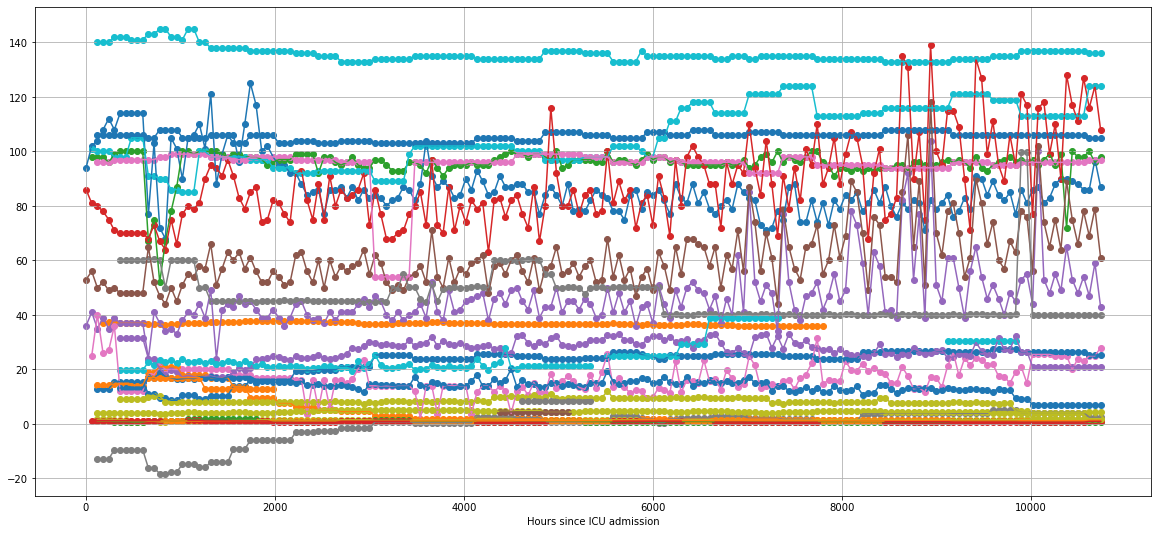

In [16]:
all_series = dataframe_from_csv(os.path.join(path_timeseries, str(ICUstayID), 'imputed_raw_timeseries_60min.csv'))

vitals = ['Heart Rate', 'Temperature Central', 'SpO2', 'Invasive systolic arterial pressure',
          'Invasive diastolic arterial pressure', 'Invasive mean arterial pressure', 'Respiratory Rate',
          
          'Base Excess', 'Carboxy Hemoglobin', 'Hemoglobin', 'Bicarbonate', 'Lactate',
          'Methemoglobin', 'pH', 'pCO2',  'PO2', 'Oxygen Saturation_SO2', 'BNP', 'Potassium', 'Sodium', 
          'Chloride', 'Calcium Ionized', 'Calcium', 'Phosphate', 'ETCO2',  'ICP', 'TOF', 'FIO2', 'Peep', 
          'Plateau Pressure', 'Mean Inspiratory Airway Pressure', 'Amylase', 'Lipase', 'Cortisol', 'pH Liquor', 
          'Lactate Liquor', 'Glucose Liquor', 'pH Drain',]

all_series = all_series.head(180)

hours = all_series.loc[all_series.patientid == ICUstayID].datetime.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in vitals:
    ax.scatter(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
#     ax.legend(vitals)
    plt.xlabel('Hours since ICU admission')
    
for col in vitals:    
    ax.plot(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
plt.grid()    
plt.show()

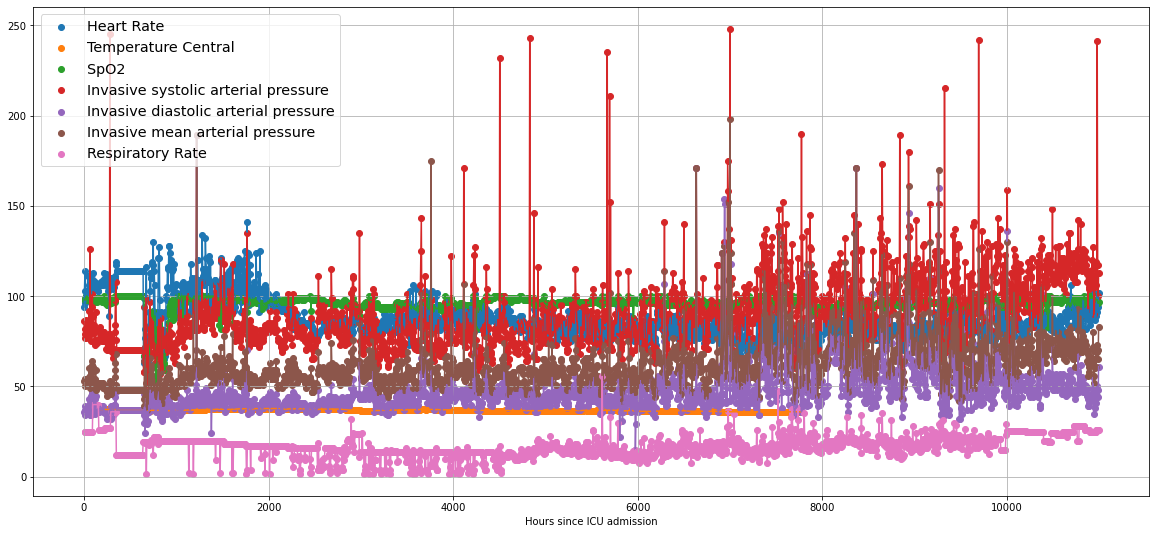

In [6]:
all_series = dataframe_from_csv(os.path.join(path_timeseries, str(ICUstayID), 'imputed_raw_timeseries_05min.csv'))

vitals = ['Heart Rate', 'Temperature Central', 'SpO2', 'Invasive systolic arterial pressure',
          'Invasive diastolic arterial pressure', 'Invasive mean arterial pressure', 'Respiratory Rate']

all_series = all_series.head(2200)

hours = all_series.loc[all_series.patientid == ICUstayID].datetime.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in vitals:
    ax.scatter(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
    ax.legend(vitals, fontsize='x-large')
    plt.xlabel('Hours since ICU admission')
    
for col in vitals:    
    ax.plot(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
plt.grid()    
plt.show()

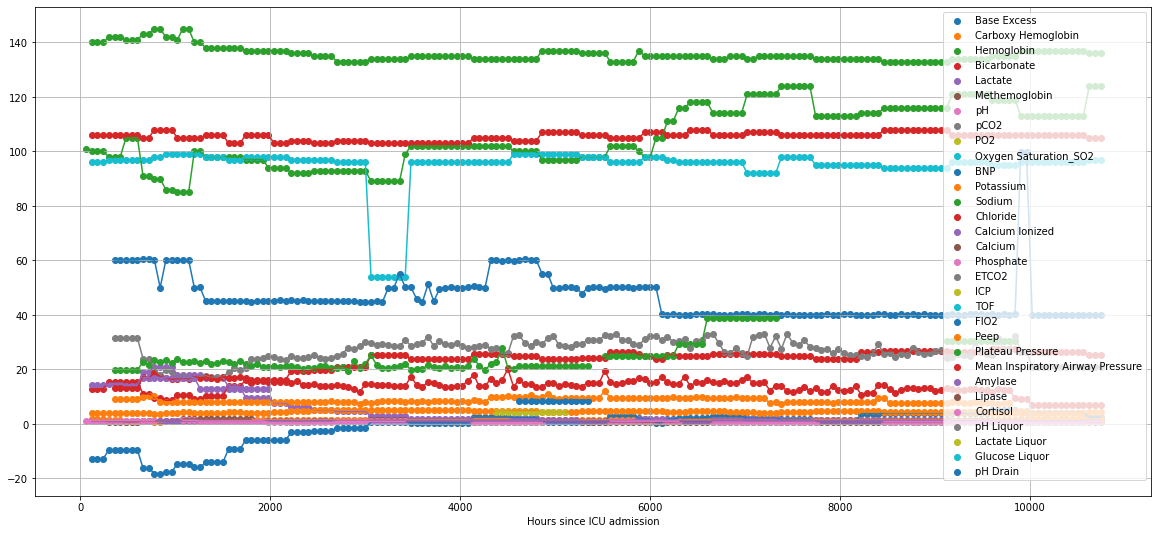

In [29]:
all_series = dataframe_from_csv(os.path.join(path_timeseries, str(ICUstayID), 'imputed_raw_timeseries_60min.csv'))

vitals = ['Base Excess', 'Carboxy Hemoglobin', 'Hemoglobin', 'Bicarbonate', 'Lactate',
          'Methemoglobin', 'pH', 'pCO2',  'PO2', 'Oxygen Saturation_SO2', 'BNP', 'Potassium', 'Sodium', 
          'Chloride', 'Calcium Ionized', 'Calcium', 'Phosphate', 'ETCO2',  'ICP', 'TOF', 'FIO2', 'Peep', 
          'Plateau Pressure', 'Mean Inspiratory Airway Pressure', 'Amylase', 'Lipase', 'Cortisol', 'pH Liquor', 
          'Lactate Liquor', 'Glucose Liquor', 'pH Drain',]

all_series = all_series.head(180)

hours = all_series.loc[all_series.patientid == ICUstayID].datetime.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in vitals:
    ax.scatter(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
    ax.legend(vitals)
    plt.xlabel('Hours since ICU admission')
    
for col in vitals:    
    ax.plot(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
plt.grid()    
plt.show()

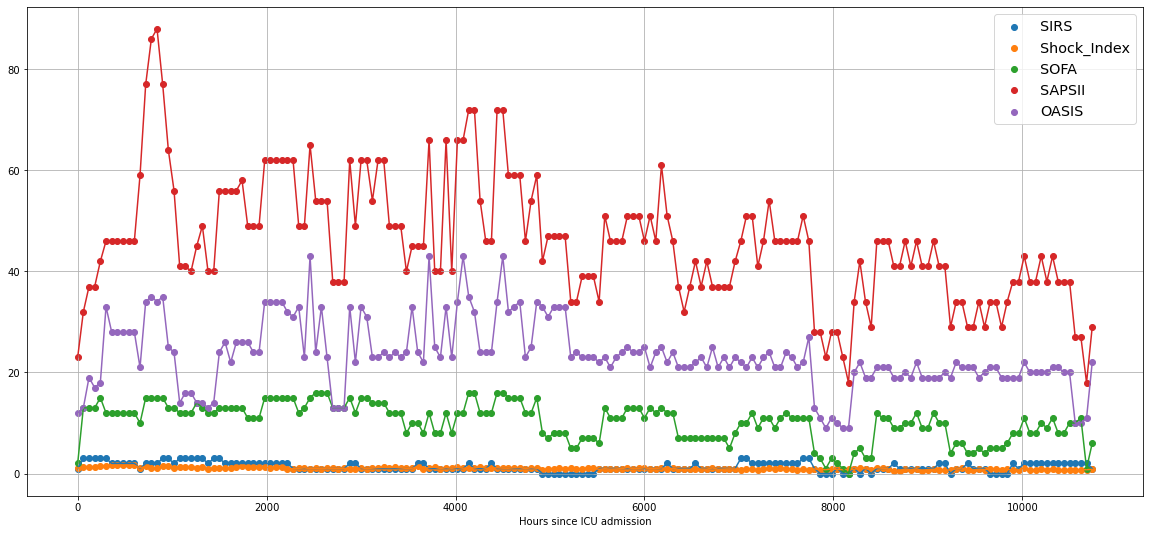

In [17]:
scores = ['SIRS','Shock_Index', 'SOFA', 'SAPSII', 'OASIS']

hours = all_series.loc[all_series.patientid == ICUstayID].datetime.max()

fig, ax = plt.subplots(figsize=(20,9))

for col in scores:
    ax.scatter(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
    ax.legend(scores, fontsize='x-large')
    plt.xlabel('Hours since ICU admission')
    
for col in scores:    
    ax.plot(all_series.loc[all_series.patientid == ICUstayID,'datetime'], all_series.loc[all_series.patientid == ICUstayID,col])
plt.grid()    
plt.show()